# TP 3: Réseau de neurone MLP - régression avec Keras

### Construction d'un réseau de neurones avec Keras

## Import des librairies

In [1]:
# Ignore warnings
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=all, 1=info, 2=warning, 3=error only
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

import pandas as pd
import matplotlib.pyplot as plt
# réglage des paramètres pour graphiques
plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

## Chargement des données

In [2]:
# extra code – load and split the California housing dataset, like earlier
housing = fetch_california_housing()

## Split des données en train/validation/test sets

In [3]:
# Séparation des données de test
X_train_full, X_test, y_train_full, y_test = train_test_split(
    housing.data, housing.target, random_state=42)
# Création train set + validation set sur les données restantes
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, random_state=42)

## Construction du MLP avec Keras

In [4]:
# Fixe le caractère aléatoire du modèle pour reproductibilité
tf.random.set_seed(42)
# Création d'une couche pour normailser les données du train set (entre 0 et 1)
norm_layer = layers.Normalization(input_shape=X_train.shape[1:])

# Création de l'architecture du réseau de neurones MLP
model = keras.Sequential([
    norm_layer,
    layers.Dense(50, activation="relu"),
    layers.Dense(50, activation="relu"),
    layers.Dense(50, activation="relu"),
    layers.Dense(1)
])

# Réglage des paramètres du modèle
# Optimiseur utilisé pour réduire l'erreur => descente de gradient ajustant les poids du modèle
optimizer = keras.optimizers.Adam(learning_rate=1e-3)
# Préparation de l'entraînement. Précise fonction de perte (MSE), algo d'optimisation de la MSE, metric d'évaluation (RMSE)
model.compile(loss="mse", optimizer=optimizer, metrics=["RootMeanSquaredError"])
# Préciser que la normalisation se fait sur les données du train set
norm_layer.adapt(X_train)
# Entrainement du modèle sur train set
history = model.fit(X_train, y_train,
                    epochs=50,
                    batch_size=32,
                    validation_data=(X_valid, y_valid))

Epoch 1/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - RootMeanSquaredError: 0.9274 - loss: 0.8601 - val_RootMeanSquaredError: 0.6124 - val_loss: 0.3750
Epoch 2/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.6231 - loss: 0.3883 - val_RootMeanSquaredError: 0.6115 - val_loss: 0.3740
Epoch 3/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5943 - loss: 0.3531 - val_RootMeanSquaredError: 0.5797 - val_loss: 0.3360
Epoch 4/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5806 - loss: 0.3371 - val_RootMeanSquaredError: 0.5814 - val_loss: 0.3381
Epoch 5/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5701 - loss: 0.3250 - val_RootMeanSquaredError: 0.7186 - val_loss: 0.5164
Epoch 6/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5675 - loss: 0.3221 - val_RootMeanSquaredError: 0.6591 - val_loss: 0.4345
Epoch 7/50
363/363 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - RootMeanSquaredError: 0.5593 - los

### Explication 363/363

Il s'agit du nombre de batches par epoch

In [5]:
# nombre de valeurs dans train set
len(X_train)

11610

In [6]:
# 1 epoch = 363 batches (passages)
363 * 32

11616

### Evaluation du modèle sur le test set

In [7]:
# Calcul erreur RMSE
mse_test, rmse_test = model.evaluate(X_test, y_test)

162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 753us/step - RootMeanSquaredError: 0.5229 - loss: 0.2734


In [8]:
rmse_test

0.5228676199913025

On voit que l'erreur de prévision est supérieur sur des données nouvelles

### Exemple d'utilisation du modèle de prévision

In [9]:
X_new = X_test[:3]
y_pred = model.predict(X_new)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


In [10]:
y_pred

array([[0.4061591],
       [0.9928992],
       [5.3316016]], dtype=float32)

## Résumé de l'architecture du modèle

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 8)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,822 (65.72 KB)

 Trainable params: 5,601 (21.88 KB)

 Non-trainable params: 17 (72.00 B)

 Optimizer params: 11,204 (43.77 KB)

Explication du nombre de paramètres par couche

- couche 1 = 17 paramètres: 8 features × (moyenne + écart type) + 1 epsilon = 16 + 1 = 17 (dont seulement 8 utilisés pour l'entraînement)
- couche 2 = 450 paramètres (poids = 8 x 50 = 400 + 50 biais)
- couche 3 = 2550 paramètres (poids = 50 x 50 = 2500 + 50 biais)  
- couche 4 = 2550 paramètres (poids = 50 x 50 = 2500 + 50 biais)
- couche 5 = 51 paramètres (poids = 50 x 1 + 1 biais)

### Représentation graphique de l'apprentissage

In [12]:
rmse_df = pd.DataFrame(history.history)
rmse_df.head()

,RootMeanSquaredError,loss,val_RootMeanSquaredError,val_loss
0,0.927420,0.860109,0.612413,0.375049
1,0.623117,0.388274,0.611535,0.373975
2,0.594260,0.353145,0.579694,0.336045
3,0.580613,0.337111,0.581445,0.338078
4,0.570089,0.325001,0.718588,0.516368


In [13]:
rmse_df = rmse_df[['RootMeanSquaredError', 'val_RootMeanSquaredError']]

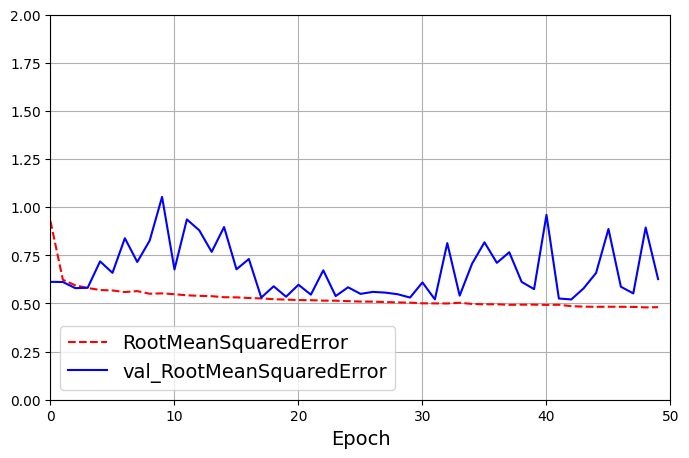

In [14]:
rmse_df.plot(
    figsize=(8, 5), xlim=[0, 50], ylim=[0, 2], grid=True, xlabel="Epoch",
    style=["r--", "b-"])
plt.legend(loc="lower left")  # extra code
plt.show()